In [57]:
import pandas as pd

df = pd.read_pickle("/home/craz/crypto/crypto-trading/find_in_out_strategy/result/2025-10-01_2025-11-30/c2/paras_0.07_0.031_0.001/trade_log.pkl")

# df = pd.read_pickle("/home/craz/crypto/crypto-trading/find_in_out_strategy/result/c2_prof_0.07_loss_0.02_incr_0.002/trade_log.pkl")


# pd.set_option('display.max_rows', None)  
df.head(10)

,entry_time,entry_price,exit_time,exit_price,exit_reason,pnl,symbol,holding_minutes,parameters
1107,2025-10-01 07:15:00,0.076310,2025-10-01 16:45:00,0.078947,take_profit,-0.035535,SLERFUSDT,570.0,"{'A': 0.07, 'B': 0.031, 'C': 0.001}"
800,2025-10-01 10:15:00,0.198500,2025-10-01 21:21:00,0.202568,take_profit,-0.021483,NEWTUSDT,666.0,"{'A': 0.07, 'B': 0.031, 'C': 0.001}"
1128,2025-10-01 12:30:00,0.892800,2025-10-01 12:35:00,0.859018,stop_loss,0.036819,SOMIUSDT,5.0,"{'A': 0.07, 'B': 0.031, 'C': 0.001}"
826,2025-10-01 12:45:00,0.001544,2025-10-01 23:39:00,0.001589,take_profit,-0.030361,NOTUSDT,654.0,"{'A': 0.07, 'B': 0.031, 'C': 0.001}"
1279,2025-10-01 13:45:00,0.025100,2025-10-01 17:11:00,0.026464,take_profit,-0.055334,VANRYUSDT,206.0,"{'A': 0.07, 'B': 0.031, 'C': 0.001}"
1348,2025-10-01 16:45:00,0.010820,2025-10-02 09:30:00,0.011074,take_profit,-0.024471,ZILUSDT,1005.0,"{'A': 0.07, 'B': 0.031, 'C': 0.001}"
1338,2025-10-01 16:45:00,5517.000000,2025-10-02 09:53:00,5603.804640,take_profit,-0.016726,YFIUSDT,1028.0,"{'A': 0.07, 'B': 0.031, 'C': 0.001}"
1049,2025-10-01 16:45:00,0.272600,2025-10-02 08:09:00,0.279991,take_profit,-0.028101,SANDUSDT,924.0,"{'A': 0.07, 'B': 0.031, 'C': 0.001}"
1062,2025-10-01 20:15:00,0.163800,2025-10-01 20:29:00,0.175086,take_profit,-0.069864,SCRTUSDT,14.0,"{'A': 0.07, 'B': 0.031, 'C': 0.001}"
727,2025-10-01 20:15:00,0.175600,2025-10-02 06:14:00,0.178845,take_profit,-0.019468,MELANIAUSDT,599.0,"{'A': 0.07, 'B': 0.031, 'C': 0.001}"


In [2]:
import pandas as pd
import matplotlib.pyplot as plt


def day_statistics(df: pd.DataFrame) -> None:
    """计算并展示每日 entry 次数的分布和描述统计信息，并绘制相关图表。

    参数:
        df (pd.DataFrame): 包含 'entry_time' 列的 DataFrame。
    """

    df["entry_time"] = pd.to_datetime(df["entry_time"], errors="coerce")

    daily_counts = (
        df.dropna(subset=["entry_time"])
        .groupby(df["entry_time"].dt.floor("D"))
        .size()
        .rename("n_entries")
        .sort_index()
    )

    full_idx = pd.date_range(daily_counts.index.min(), daily_counts.index.max(), freq="D")
    daily_counts_full = daily_counts.reindex(full_idx, fill_value=0)
    daily_counts_full.index.name = "date"


    dist = daily_counts_full.value_counts().sort_index()
    dist.index.name = "entries_per_day"
    dist.name = "num_days"

    print("\n每日 entry 次数的分布：")
    print(dist)

    print("\n每日次数描述统计：")
    print(daily_counts_full.describe())


    plt.figure()
    daily_counts_full.plot()
    plt.title("Entries per day")
    plt.xlabel("Date")
    plt.ylabel("# entries")
    plt.tight_layout()
    plt.show()

    plt.figure()
    plt.hist(daily_counts_full.values, bins=30)
    plt.title("Distribution of entries per day")
    plt.xlabel("# entries per day")
    plt.ylabel("# days")
    plt.tight_layout()
    plt.show()

# day_statistics(df_filter_test)


Trade stats: Count: 1372 Win Rate: 50.87% Avg PnL: 0.36% Avg Hold: 750.7m Avg Win: 4.59% Avg Loss: -4.03% P/L Ratio: 1.14  Daily stats (from daily_return): Days used: 61 / 61 Avg Daily Return: 0.80% Daily Win Rate: 54.10% Avg Win Day: 3.59% Avg Loss Day: -2.49% P/L Ratio: 1.44


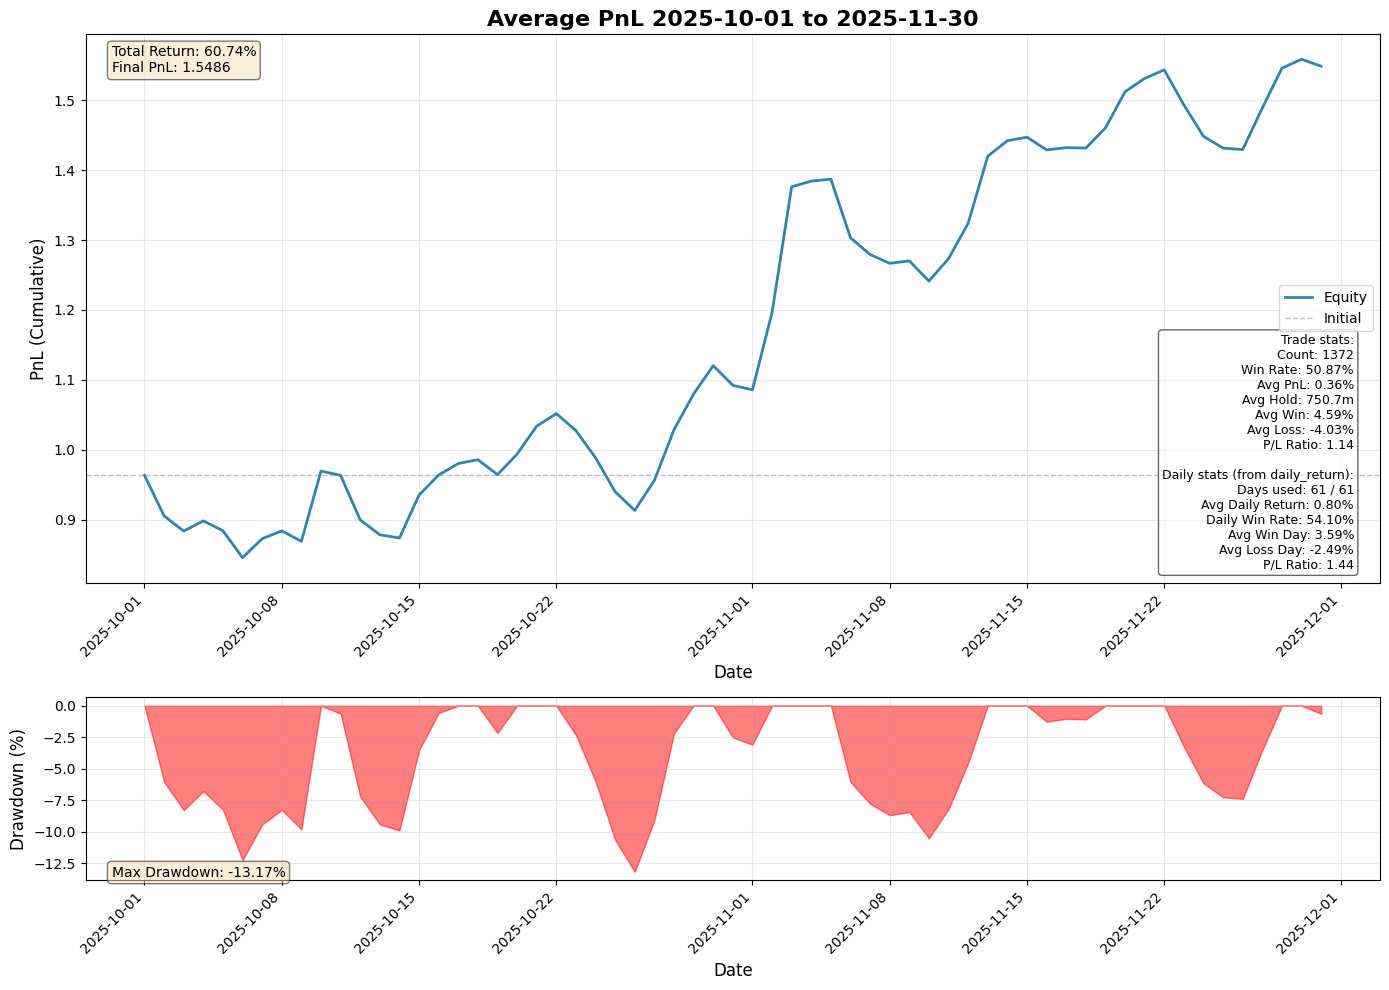

In [14]:
from __future__ import annotations

from typing import Optional, Union
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


def _normalize_timestamp(ts: Union[str, pd.Timestamp]) -> pd.Timestamp:
    out = pd.to_datetime(ts)
    if getattr(out, "tzinfo", None) is not None:
        out = out.tz_convert(None)
    return out


def present_pnl_df(
    trade_df: pd.DataFrame,
    *,
    start_time: Union[str, pd.Timestamp, None] = None,
    end_time: Union[str, pd.Timestamp, None] = None,
    initial_capital: float = 1.0,
    date_freq: str = "D",
    entry_time_col: str = "entry_time",
    exit_time_col: str = "exit_time",
    pnl_col: str = "pnl",
    holding_col: str = "holding_minutes",
    title_prefix: str = "Average PnL",
    include_flat_days_in_daily_stats: bool = False,  # daily_return==0 是否纳入“交易天统计”
) -> tuple[pd.Series, pd.Series]:
    """
    - 统计1：按每笔交易（保留你之前的统计）
    - 统计2：按交易天 daily_return（新增）
    - 曲线：仍然使用 daily_return 复利生成 capital_series（与你之前一致）
    返回：(capital_series, daily_return)
    """
    if trade_df is None or trade_df.empty:
        print("Empty trade_df; skip presentation.")
        return pd.Series(dtype=float), pd.Series(dtype=float)

    df = trade_df.copy()

    # ---- 基础清洗 ----
    if entry_time_col not in df.columns or pnl_col not in df.columns:
        raise ValueError(f"trade_df must contain columns: {entry_time_col}, {pnl_col}")

    df[entry_time_col] = pd.to_datetime(df[entry_time_col], errors="coerce")
    if exit_time_col in df.columns:
        df[exit_time_col] = pd.to_datetime(df[exit_time_col], errors="coerce")
    df[pnl_col] = pd.to_numeric(df[pnl_col], errors="coerce")

    df = df.dropna(subset=[entry_time_col, pnl_col]).sort_values(by=entry_time_col)

    # =========================
    # 统计(1)：按每笔交易（原有）
    # =========================
    pnls = df[pnl_col].astype(float).to_numpy()
    wins = pnls[pnls > 0]
    losses = pnls[pnls <= 0]

    holding_vals = np.array([])
    if holding_col in df.columns:
        holding_vals = pd.to_numeric(df[holding_col], errors="coerce").dropna().to_numpy()

    win_rate = float((pnls > 0).mean()) if pnls.size else 0.0
    avg_pnl = float(pnls.mean()) if pnls.size else 0.0
    avg_holding = float(holding_vals.mean()) if holding_vals.size else 0.0
    avg_win = float(wins.mean()) if wins.size else 0.0
    avg_loss = float(losses.mean()) if losses.size else 0.0
    profit_loss_ratio = (avg_win / abs(avg_loss)) if avg_loss < 0 else float("nan")

    trade_stats_text = (
        "Trade stats:\n"
        f"Count: {len(df)}\n"
        f"Win Rate: {win_rate:.2%}\n"
        f"Avg PnL: {avg_pnl:.2%}\n"
        f"Avg Hold: {avg_holding:.1f}m\n"
        f"Avg Win: {avg_win:.2%}\n"
        f"Avg Loss: {avg_loss:.2%}\n"
        f"P/L Ratio: {profit_loss_ratio:.2f}"
    )

    # =========================
    # 曲线：daily_return + capital_series（原有）
    # =========================
    if start_time is None:
        start_ts = df[entry_time_col].min().normalize()
    else:
        start_ts = _normalize_timestamp(start_time).normalize()

    if end_time is None:
        end_ts = df[entry_time_col].max().normalize()
    else:
        end_ts = _normalize_timestamp(end_time).normalize()

    if end_ts < start_ts:
        raise ValueError(f"end_time < start_time: {end_ts} < {start_ts}")

    daily_index = pd.date_range(start_ts, end_ts, freq=date_freq)
    df["entry_date"] = df[entry_time_col].dt.normalize()

    daily_return = (
        df.groupby("entry_date")[pnl_col]
        .sum()
        .mul(0.1)
        .reindex(daily_index, fill_value=0.0)
        .astype(float)
    )

    capital_series = (1.0 + daily_return).cumprod() * float(initial_capital)

    # =========================
    # 统计(2)：按交易天 daily_return（新增）
    # =========================
    dr_used = daily_return if include_flat_days_in_daily_stats else daily_return[daily_return != 0]

    if len(dr_used) == 0:
        daily_stats_text = (
            "Daily stats (from daily_return):\n"
            f"Days used: 0 / {len(daily_return)}\n"
            "Avg Daily Return: N/A\n"
            "Daily Win Rate: N/A\n"
            "Avg Win Day: N/A\n"
            "Avg Loss Day: N/A\n"
            "P/L Ratio: N/A"
        )
    else:
        daily_avg = float(dr_used.mean())
        daily_win_rate = float((dr_used > 0).mean())
        avg_win_day = float(dr_used[dr_used > 0].mean()) if (dr_used > 0).any() else 0.0
        avg_loss_day = float(dr_used[dr_used <= 0].mean()) if (dr_used <= 0).any() else 0.0
        daily_pl_ratio = (avg_win_day / abs(avg_loss_day)) if avg_loss_day < 0 else float("nan")

        daily_stats_text = (
            "Daily stats (from daily_return):\n"
            f"Days used: {len(dr_used)} / {len(daily_return)}\n"
            f"Avg Daily Return: {daily_avg:.2%}\n"
            f"Daily Win Rate: {daily_win_rate:.2%}\n"
            f"Avg Win Day: {avg_win_day:.2%}\n"
            f"Avg Loss Day: {avg_loss_day:.2%}\n"
            f"P/L Ratio: {daily_pl_ratio:.2f}"
        )

    # 合并两段统计文本（用于图中显示）
    stats_text = trade_stats_text + "\n\n" + daily_stats_text
    print(stats_text.replace("\n", " "))

    _plot_pnl_curve(
        capital_series,
        title=f"{title_prefix} {start_ts.date()} to {end_ts.date()}",
        stats_text=stats_text,
    )

    return capital_series, daily_return


def _plot_pnl_curve(
    pnl_series: pd.Series,
    *,
    title: str,
    stats_text: Optional[str] = None,
) -> None:
    if pnl_series is None or len(pnl_series) < 2:
        raise ValueError("Insufficient data points to plot.")

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), height_ratios=[3, 1])

    ax1.plot(pnl_series.index, pnl_series.values, linewidth=2, color="#2E86AB", label="Equity")
    ax1.axhline(y=pnl_series.iloc[0], color="gray", linestyle="--", linewidth=1, alpha=0.5, label="Initial")

    ax1.set_title(title, fontsize=16, fontweight="bold")
    ax1.set_xlabel("Date", fontsize=12)
    ax1.set_ylabel("PnL (Cumulative)", fontsize=12)
    ax1.legend(loc="best", fontsize=10)
    ax1.grid(True, alpha=0.3)

    ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
    ax1.xaxis.set_major_locator(mdates.AutoDateLocator())
    plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha="right")

    total_return = (pnl_series.iloc[-1] / pnl_series.iloc[0] - 1) * 100
    summary_text = f"Total Return: {total_return:.2f}%\nFinal PnL: {pnl_series.iloc[-1]:.4f}"
    ax1.text(
        0.02,
        0.98,
        summary_text,
        transform=ax1.transAxes,
        fontsize=10,
        verticalalignment="top",
        bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5),
    )
    if stats_text is not None:
        ax1.text(
            0.98,
            0.02,
            stats_text,
            transform=ax1.transAxes,
            fontsize=9,
            verticalalignment="bottom",
            horizontalalignment="right",
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.6),
        )

    running_max = pnl_series.cummax()
    drawdown = (pnl_series - running_max) / running_max * 100
    ax2.fill_between(drawdown.index, 0, drawdown.values, color="red", alpha=0.5)

    ax2.set_xlabel("Date", fontsize=12)
    ax2.set_ylabel("Drawdown (%)", fontsize=12)
    ax2.grid(True, alpha=0.3)
    ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
    ax2.xaxis.set_major_locator(mdates.AutoDateLocator())
    plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha="right")

    max_dd = float(drawdown.min())
    ax2.text(
        0.02,
        0.02,
        f"Max Drawdown: {max_dd:.2f}%",
        transform=ax2.transAxes,
        fontsize=10,
        bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5),
    )

    plt.tight_layout()
    plt.show()
    plt.close(fig)

capital, daily_return = present_pnl_df(df)

In [97]:
# import pandas as pd

# def filter_by_entry_time(df: pd.DataFrame, start, end) -> pd.DataFrame:
#     d = df.copy()
#     d["entry_time"] = pd.to_datetime(d["entry_time"])
#     start = pd.to_datetime(start)
#     end = pd.to_datetime(end)
#     return d[(d["entry_time"] >= start) & (d["entry_time"] <= end)]

# filter_by_entry_time(df, "2025-01-14 00:00:00", "2025-01-16 00:00:00")

In [15]:

mask = (df['entry_time'] < '2025-11-01') 
df_train = df.loc[mask]


mask = (df['entry_time'] >= '2025-11-01')
df_test = df.loc[mask] 

len(df_test)

760

In [ ]:
import pandas as pd
from scipy import stats

# 存储结果的列表
results = []

# 按 symbol 分组遍历
for symbol, group in df_train.groupby('symbol'):
    pnls = group['pnl'].dropna() # 确保没有空值
    
    # 如果样本量太少（比如少于2个），无法进行统计检验
    if len(pnls) < 2:
        continue
    
    # 进行单样本 t 检验，原假设 H0: 均值 <= 0，备择假设 H1: 均值 > 0
    # alternative='greater' 表示我们进行单侧检验，看均值是否显著大于 0
    t_stat, p_value = stats.ttest_1samp(pnls, popmean=0, alternative='greater')
    
    # 显著性水平 95%，即 alpha = 0.05
    is_significant = p_value < 0.05
    
    results.append({
        'symbol': symbol,
        'mean_pnl': pnls.mean(),
        't_stat': t_stat,
        'p_value': p_value,
        'significant_positive': is_significant
    })

# 转换为结果表格查看
results_df = pd.DataFrame(results)

# 筛选出符合条件的 symbol
successful_symbols = results_df[results_df['significant_positive'] == True]

print("统计检验结果预览：")
print(results_df.head())
print(f"\n共有 {len(successful_symbols)} 个 symbol 以 95% 的概率认为均值显著大于 0。")

统计检验结果预览：
          symbol  mean_pnl    t_stat   p_value  significant_positive
0         0GUSDT  0.058647  1.112183  0.233110                 False
1  1000FLOKIUSDT -0.004708 -0.135719  0.542938                 False
2   1000RATSUSDT  0.017548  0.807388  0.283795                 False
3    1000WHYUSDT -0.008631 -6.285614  0.949780                 False
4    1000XECUSDT -0.003768 -0.056770  0.520055                 False

共有 20 个 symbol 以 95% 的概率认为均值显著大于 0。


Trade stats: Count: 760 Win Rate: 49.61% Avg PnL: 0.49% Avg Hold: 745.8m Avg Win: 5.04% Avg Loss: -3.98% P/L Ratio: 1.27  Daily stats (from daily_return): Days used: 30 / 30 Avg Daily Return: 1.25% Daily Win Rate: 60.00% Avg Win Day: 3.26% Avg Loss Day: -1.77% P/L Ratio: 1.84


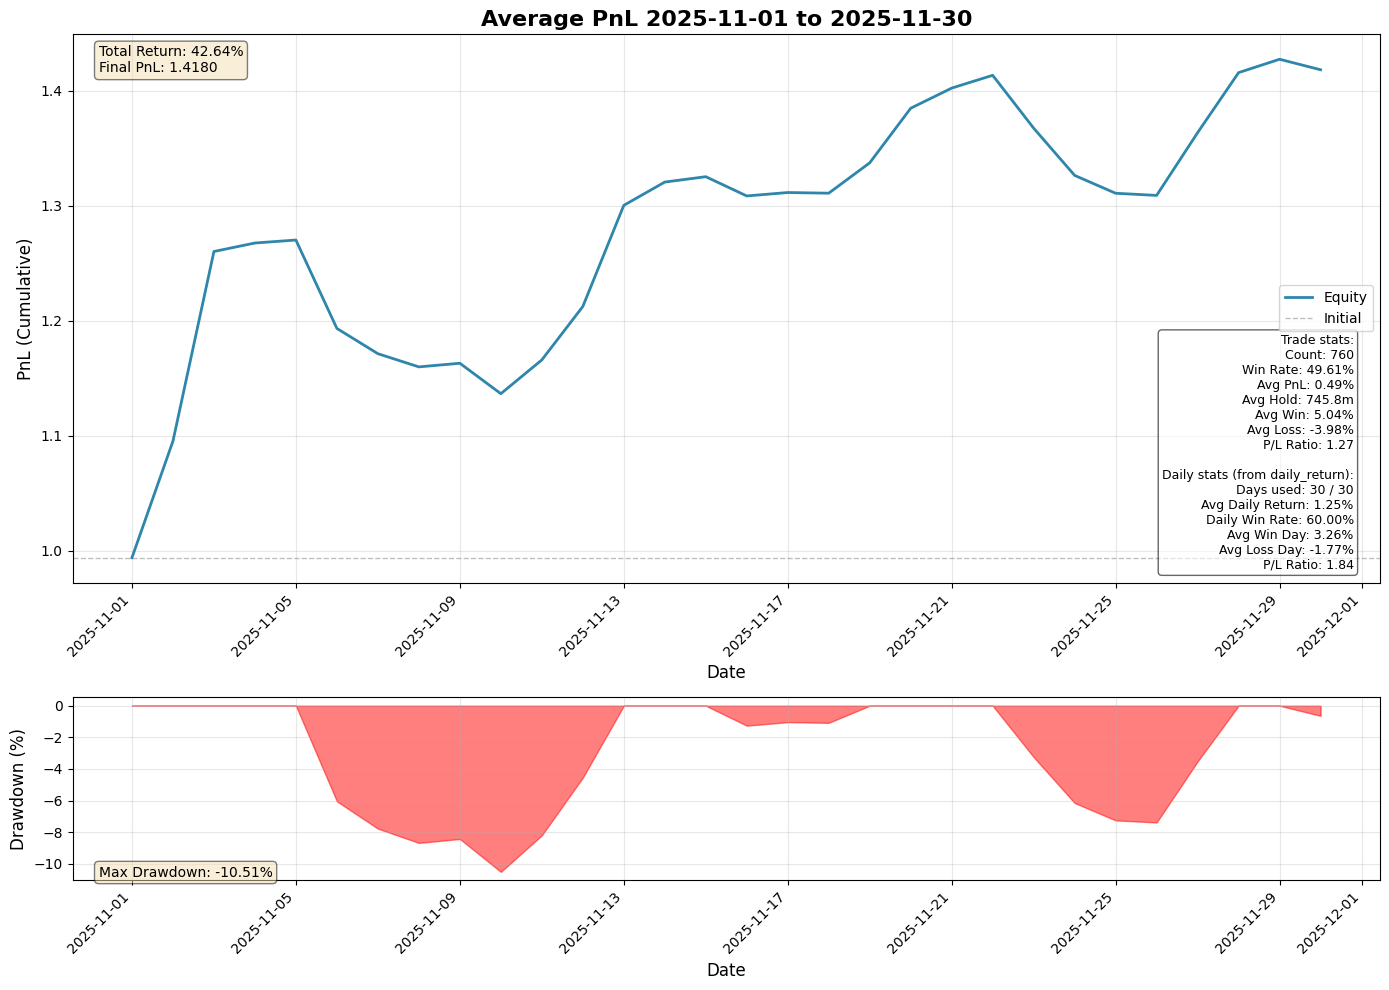

In [48]:
_, _ = present_pnl_df(df_test)

Trade stats: Count: 56 Win Rate: 51.79% Avg PnL: 1.12% Avg Hold: 813.3m Avg Win: 5.97% Avg Loss: -4.09% P/L Ratio: 1.46  Daily stats (from daily_return): Days used: 20 / 27 Avg Daily Return: 0.31% Daily Win Rate: 55.00% Avg Win Day: 0.99% Avg Loss Day: -0.52% P/L Ratio: 1.92


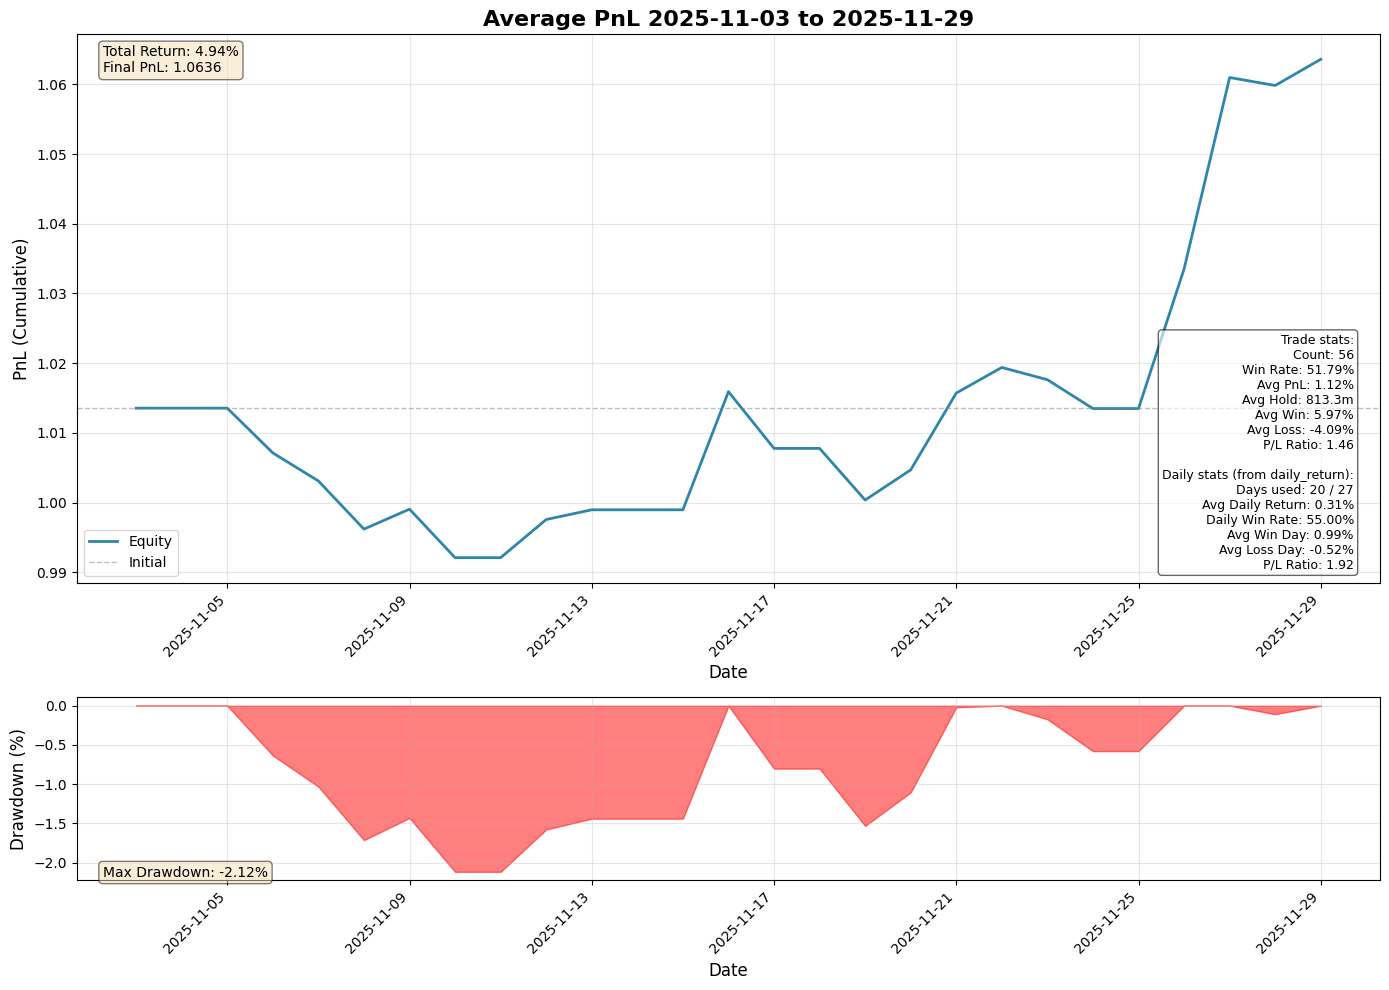

In [49]:
df_filter_test = df_test[df_test['symbol'].isin(successful_symbols['symbol'])]
_, _ = present_pnl_df(df_filter_test)

TypeError: 'float' object cannot be interpreted as an integer